Inameti Mercy Etim - 
 SCA/APC3/DS/147

In [1]:
# Importing all neccessary libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading the dataset
df1 = pd.read_excel("raw_night_1854_1855.xlsx")
df2 = pd.read_excel("raw_night_1855_1856.xlsx")

In [3]:
df1.head()

,Month,Avg Army Size,Disease Deaths,Wounds,Other Causes
0,Apr 1854,8571,1,0,5
1,May 1854,23333,12,0,9
2,Jun 1854,28333,11,0,6
3,Jul 1854,28722,359,0,23
4,Aug 1854,30246,828,1,30


In [4]:
df2.head()

,Month,Avg Army Size,Disease Deaths,Wounds,Other Causes
0,Apr 1855,32393,477,48,57
1,May 1855,35693,508,32,37
2,Jun 1855,40253,802,31,31
3,Jul 1855,35786,382,30,33
4,Aug 1855,51074,483,41,55


In [5]:
# Adding period column (so we can seperate later)
df1["Period"] = "1854-1855"
df2["Period"] = "1855-1856"

In [6]:
# Combining both datasets
df = pd.concat([df1, df2], ignore_index=True)

In [7]:
df.head()

,Month,Avg Army Size,Disease Deaths,Wounds,Other Causes,Period
0,Apr 1854,8571,1,0,5,1854-1855
1,May 1854,23333,12,0,9,1854-1855
2,Jun 1854,28333,11,0,6,1854-1855
3,Jul 1854,28722,359,0,23,1854-1855
4,Aug 1854,30246,828,1,30,1854-1855


In [8]:
df.columns

Index(['Month', 'Avg Army Size', 'Disease Deaths', 'Wounds', 'Other Causes',
       'Period'],
      dtype='object')

In [9]:
# Splitting data into the two periods
df_1854 = df[df["Period"] == "1854-1855"]
df_1855 = df[df["Period"] == "1855-1856"]

In [10]:
# Defining coxcomb plotting function
def plot_coxcomb(ax, data, title):
    # Number of months
    N = len(data)

    # Angles for each month
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    # Normalizing by army size
    disease_rate = (data["Disease Deaths"] / data["Avg Army Size"]) * 1000
    wounds_rate = (data["Wounds"] / data["Avg Army Size"]) * 1000
    other_rate = (data["Other Causes"] / data["Avg Army Size"]) * 1000

    # Converting values to area-based radius
    disease = np.sqrt(data["Disease Deaths"])
    wounds = np.sqrt(data["Wounds"])
    other = np.sqrt(data["Other Causes"])

    # Width of each slice
    width = (2 * np.pi / N)*0.9

    # Plotting stacked bars
    ax.bar(angles, disease, width=width, color='#4F81BD', label='Disease')
    ax.bar(angles, wounds, width=width, bottom=disease, color='#C0504D', label='Wounds')
    ax.bar(angles, other, width=width, bottom=disease + wounds, color='#9FA0A0', label='Other')

    # Style to match original look
    ax.set_title(title, fontsize=12, pad=30)
    ax.set_xticks(angles)
    ax.set_xticklabels(data["Month"], fontsize=7)

    ax.set_yticklabels([])  # remove radial labels
    ax.set_theta_offset(np.pi / 2)  # start at top
    ax.set_theta_direction(-1)  # clockwise

    ax.grid(True, linestyle = '--', alpha = 0.3)

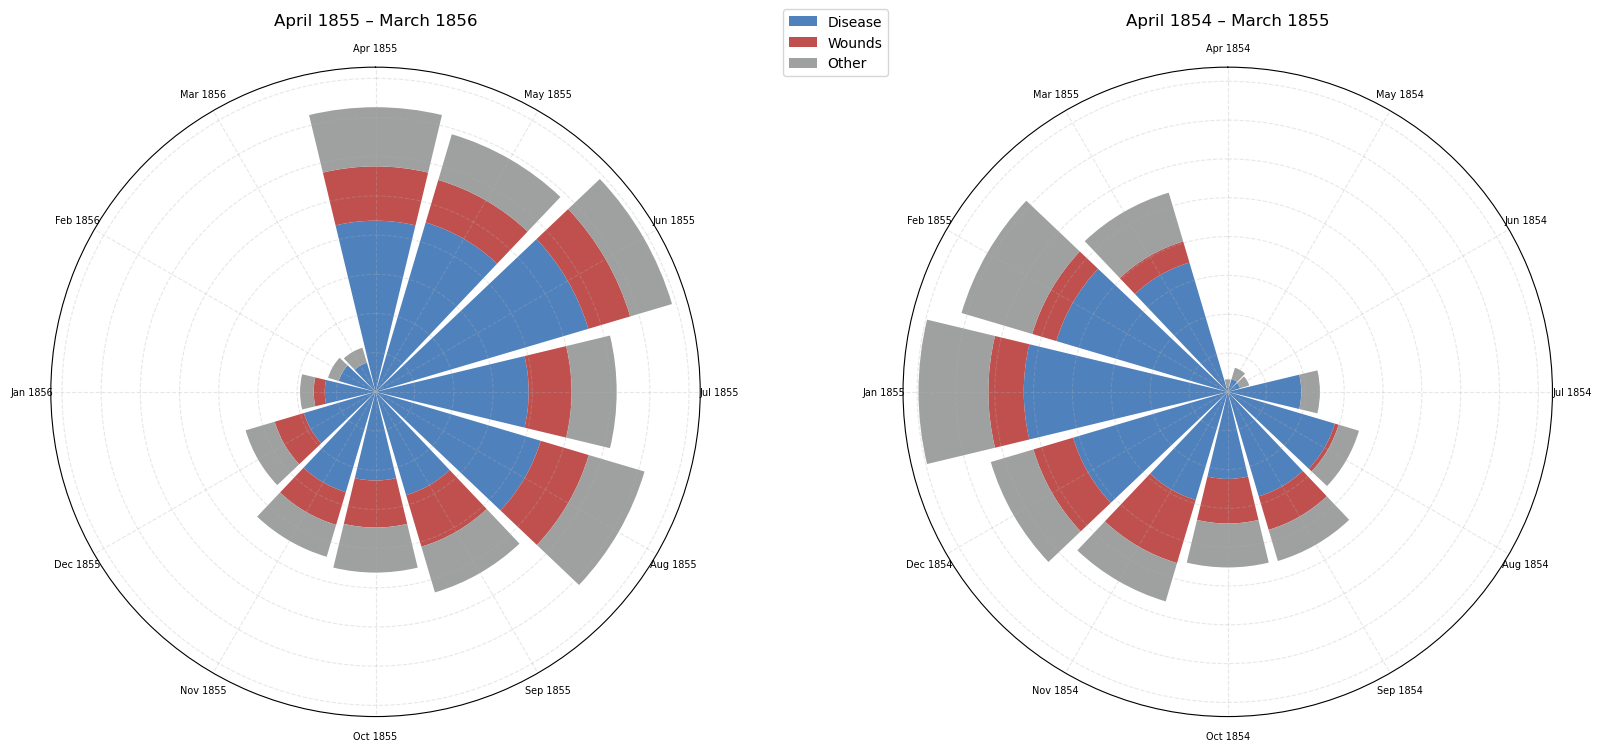

In [12]:
# Creating the two circular plots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(16,8))

plot_coxcomb(axes[0], df_1855, "April 1855 – March 1856")
plot_coxcomb(axes[1], df_1854, "April 1854 – March 1855")

# add legend once
axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.subplots_adjust(top = 0.80)
plt.tight_layout()
plt.savefig("My_chart.png")
plt.show()

The coxcomb charts show the main causes of death among soldiers during 1854–1855 and 1855–1856. Disease was by far the leading cause, represented by the largest sections in both charts. Although deaths from disease decreased slightly in the second period, they remained far higher than deaths from wounds or other causes. Wounds were consistently the second-highest cause, while other causes contributed very little.

Comparing the two periods, the slight decline in disease-related deaths may reflect improvements in sanitation, medical care, or camp management. Wound-related deaths stayed roughly the same, showing that combat injuries remained a persistent risk. Other causes had minimal impact across both years, indicating they were less significant for overall mortality.

These trends highlight the overwhelming effect of disease on soldiers’ survival during this time. The charts emphasize the importance of preventive healthcare, hygiene, and timely medical treatment in military settings. Understanding these patterns demonstrates how non-combat factors can dominate mortality and the value of focusing on health strategies alongside battlefield readiness.